# 第 1 步：数据准备与预处理

本 notebook 完成以下任务：
1. 检查并安装依赖
2. 从 GitHub 下载公开时间序列数据集（ETTh1、ECL）
3. 数据预处理：归一化（使用训练集统计量）、滑动窗口划分样本
4. 按时间顺序切分训练/验证/测试集，确保无数据泄露

**使用的数据集**：ETTh1（小时级，少变量）、ETTm1（15分钟级，高频）、ECL（小时级，多变量321个）

## 1. 环境检查与依赖安装

In [11]:
import sys
import subprocess

# 检查并安装缺失的依赖
required = {'torch': 'torch', 'pandas': 'pandas', 'numpy': 'numpy',
            'sklearn': 'scikit-learn', 'matplotlib': 'matplotlib'}
missing = []
for import_name, pip_name in required.items():
    try:
        __import__(import_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f'安装缺失依赖: {missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install'] + missing)
else:
    print('所有依赖已就绪')

所有依赖已就绪


In [12]:
import os
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# 解决中文乱码：设置跨平台兼容字体
def setup_chinese_font():
    """配置 matplotlib 中文字体，兼容 Windows 和 Mac"""
    font_candidates = [
        'Microsoft YaHei',      # Windows 微软雅黑
        'PingFang SC',          # Mac 苹方
        'SimHei',               # Windows 黑体
        'Heiti SC',             # Mac 黑体
        'Arial Unicode MS',     # 跨平台通用
        'WenQuanYi Micro Hei',  # Linux
        'sans-serif',
    ]
    available = set(f.name for f in matplotlib.font_manager.fontManager.ttflist)
    chosen = None
    for f in font_candidates:
        if f in available:
            chosen = f
            break
    if chosen:
        plt.rcParams['font.sans-serif'] = [chosen] + plt.rcParams['font.sans-serif']
        print(f'字体设置: {chosen}')
    else:
        plt.rcParams['font.sans-serif'] = font_candidates
        print('字体设置: 使用默认回退列表')
    plt.rcParams['axes.unicode_minus'] = False

setup_chinese_font()

print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

# 项目根目录
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(ROOT, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
print(f'数据目录: {DATA_DIR}')

字体设置: Microsoft YaHei
PyTorch: 2.10.0+cu126
NumPy: 2.3.5
Pandas: 3.0.1
CUDA available: True
数据目录: c:\Users\LOKER\Desktop\Research-Training\data


## 2. 从 GitHub 下载数据集

数据集来源：
- ETT: [zhouhaoyi/ETDataset](https://github.com/zhouhaoyi/ETDataset)
- ECL/ILI/Traffic: [thuml/Autoformer](https://github.com/thuml/Autoformer)

| 数据集 | 变量数 | 频率 | 说明 |
|--------|--------|------|------|
| ETTh1/h2 | 7 | 小时 | 电力变压器温度（2个站点） |
| ETTm1/m2 | 7 | 15分钟 | 电力变压器温度（高频） |
| ECL | 321 | 小时 | 电力消耗负荷 |
| ILI | 7 | 周 | 美国流感样病例 |
| Traffic | 862 | 小时 | 高速公路交通流量 |

In [13]:
import urllib.request

# GitHub Raw 下载链接
DATASET_URLS = {
    'ETTh1.csv':    'https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv',
    'ETTh2.csv':    'https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh2.csv',
    'ETTm1.csv':    'https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm1.csv',
    'ETTm2.csv':    'https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm2.csv',
    'ECL.csv':      'https://raw.githubusercontent.com/thuml/Autoformer/main/dataset/electricity/electricity.csv',
    'ILI.csv':      'https://raw.githubusercontent.com/thuml/Autoformer/main/dataset/illness/national_illness.csv',
    'Traffic.csv':  'https://raw.githubusercontent.com/thuml/Autoformer/main/dataset/traffic/traffic.csv',
}

for fname, url in DATASET_URLS.items():
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.exists(fpath):
        print(f'{fname} 已存在')
        continue
    print(f'下载 {fname} ...')
    try:
        urllib.request.urlretrieve(url, fpath)
        size_kb = os.path.getsize(fpath) / 1024
        print(f'  完成 ({size_kb:.0f} KB)')
    except Exception as e:
        print(f'  失败: {e}')

ETTh1.csv 已存在
ETTh2.csv 已存在
ETTm1.csv 已存在
ETTm2.csv 已存在
ECL.csv 已存在
ILI.csv 已存在
Traffic.csv 已存在


In [14]:
# 验证下载结果，并自动检测列名
csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
print(f'已下载 {len(csv_files)} 个数据集: {sorted(csv_files)}')

for f in sorted(csv_files):
    df = pd.read_csv(os.path.join(DATA_DIR, f), nrows=3)
    print(f'  {f}: 列={list(df.columns)}')

已下载 7 个数据集: ['ECL.csv', 'ETTh1.csv', 'ETTh2.csv', 'ETTm1.csv', 'ETTm2.csv', 'ILI.csv', 'Traffic.csv']
  ECL.csv: 列=['date', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140',

## 3. 数据集配置与标准化切分方案

按时间顺序切分，使用训练集的均值和标准差做归一化，避免数据泄露。

| 数据集 | 训练集 | 验证集 | 测试集 |
|--------|--------|--------|--------|
| ETTh1 | 前12个月 | 接下来4个月 | 最后4个月 |
| ETTm1 | 前12个月 | 接下来4个月 | 最后4个月 |
| ECL | 前70% | 接下来10% | 最后20% |

In [15]:
# 先读取每个数据集的列名，自动适配配置
def detect_columns(filepath):
    """检测 CSV 文件的日期列和目标列"""
    df = pd.read_csv(filepath, nrows=1)
    cols = list(df.columns)
    
    # 检测日期列
    date_col = None
    for c in cols:
        if c.lower() in ['date', 'timestamp', 'time', 'datetime']:
            date_col = c
            break
    if date_col is None:
        date_col = cols[0]  # 默认第一列
    
    # 数值列
    num_cols = [c for c in cols if c != date_col]
    
    return date_col, num_cols

# 检测所有已下载数据集的列结构
for fname in sorted(csv_files):
    fpath = os.path.join(DATA_DIR, fname)
    date_col, num_cols = detect_columns(fpath)
    print(f'{fname}: 日期列="{date_col}", 数值列数={len(num_cols)}, 目标列="{num_cols[-1]}"')

ECL.csv: 日期列="date", 数值列数=321, 目标列="OT"
ETTh1.csv: 日期列="date", 数值列数=7, 目标列="OT"
ETTh2.csv: 日期列="date", 数值列数=7, 目标列="OT"
ETTm1.csv: 日期列="date", 数值列数=7, 目标列="OT"
ETTm2.csv: 日期列="date", 数值列数=7, 目标列="OT"
ILI.csv: 日期列="date", 数值列数=7, 目标列="OT"
Traffic.csv: 日期列="date", 数值列数=862, 目标列="OT"


In [16]:
# 展示各个数据集的维度信息（划分前）
print("=" * 70)
print("各数据集维度概览（划分前）")
print("=" * 70)

dim_info = []
for fname in sorted(csv_files):
    fpath = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(fpath)
    date_col, num_cols = detect_columns(fpath)
    
    rows, cols = df.shape
    n_features = len(num_cols)
    
    # 时间范围
    df[date_col] = pd.to_datetime(df[date_col])
    date_range = f"{df[date_col].iloc[0]} ~ {df[date_col].iloc[-1]}"
    
    dim_info.append({
        '数据集': fname.replace('.csv', ''),
        '总行数': f"{rows:,}",
        '总列数': cols,
        '特征数': n_features,
        '时间范围': date_range,
        '内存占用': f"{df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB"
    })

dim_df = pd.DataFrame(dim_info)
print(dim_df.to_string(index=False))
print("=" * 70)

各数据集维度概览（划分前）
    数据集    总行数  总列数  特征数                                      时间范围     内存占用
    ECL 26,304  322  321 2016-07-01 02:00:00 ~ 2019-07-02 01:00:00  64.6 MB
  ETTh1 17,420    8    7 2016-07-01 00:00:00 ~ 2018-06-26 19:00:00   1.1 MB
  ETTh2 17,420    8    7 2016-07-01 00:00:00 ~ 2018-06-26 19:00:00   1.1 MB
  ETTm1 69,680    8    7 2016-07-01 00:00:00 ~ 2018-06-26 19:45:00   4.3 MB
  ETTm2 69,680    8    7 2016-07-01 00:00:00 ~ 2018-06-26 19:45:00   4.3 MB
    ILI    966    8    7 2002-01-01 00:00:00 ~ 2020-06-30 00:00:00   0.1 MB
Traffic 17,544  863  862 2016-07-01 02:00:00 ~ 2018-07-02 01:00:00 115.5 MB


In [ ]:
# 数据集配置（精简版：ETTh1 + ETTm1 + ECL）
DATASET_CONFIG = {
    'ETTh1': {
        'file': 'ETTh1.csv',
        'date_col': 'date',
        'target_col': 'OT',
        'freq': 'h',
        'split': [12*30*24, 4*30*24, 4*30*24],
    },
    'ETTm1': {
        'file': 'ETTm1.csv',
        'date_col': 'date',
        'target_col': 'OT',
        'freq': '15min',
        'split': [12*30*24*4, 4*30*24*4, 4*30*24*4],
    },
    'ECL': {
        'file': 'ECL.csv',
        'date_col': 'date',
        'target_col': None,  # 自动检测最后一列
        'freq': 'h',
        'split': [0.7, 0.1, 0.2],
    },
}

# 自动补全 target_col
for name, cfg in DATASET_CONFIG.items():
    fpath = os.path.join(DATA_DIR, cfg['file'])
    if not os.path.exists(fpath):
        continue
    if cfg['target_col'] is None:
        _, num_cols = detect_columns(fpath)
        cfg['target_col'] = num_cols[-1]
        print(f'{name}: 自动检测目标列 = "{cfg["target_col"]}"')

# 预测步长（覆盖短中长期：24/48/96/168/336）
PRED_HORIZONS = [24, 48, 96, 168, 336]
# 回看窗口
LOOKBACK = 96

print(f'\n数据集: {list(DATASET_CONFIG.keys())}')
print(f'预测步长: {PRED_HORIZONS}')
print(f'回看窗口: {LOOKBACK}')

## 4. 数据预处理核心函数

In [18]:
def load_dataset(name):
    """加载数据集，返回 DataFrame 和配置"""
    cfg = DATASET_CONFIG[name]
    fpath = os.path.join(DATA_DIR, cfg['file'])
    df = pd.read_csv(fpath)
    
    date_col = cfg['date_col']
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    
    num_cols = [c for c in df.columns if c != date_col]
    
    print(f'[{name}] 形状: {df.shape}, 日期范围: {df[date_col].iloc[0]} ~ {df[date_col].iloc[-1]}')
    print(f'  数值特征: {len(num_cols)} 个, 目标列: {cfg["target_col"]}')
    
    return df, cfg, num_cols


def split_dataset(df, cfg, num_cols):
    """按时间顺序切分训练/验证/测试集"""
    n = len(df)
    split = cfg['split']
    
    if isinstance(split[0], float):
        train_end = int(n * split[0])
        val_end = int(n * (split[0] + split[1]))
    else:
        train_end = min(split[0], n)
        val_end = min(split[0] + split[1], n)
    
    train_df = df.iloc[:train_end]
    val_df = df.iloc[train_end:val_end]
    test_df = df.iloc[val_end:]
    
    print(f'  训练集: {len(train_df)} ({len(train_df)/n*100:.1f}%)')
    print(f'  验证集: {len(val_df)} ({len(val_df)/n*100:.1f}%)')
    print(f'  测试集: {len(test_df)} ({len(test_df)/n*100:.1f}%)')
    
    return train_df, val_df, test_df


def normalize_data(train_df, val_df, test_df, num_cols):
    """使用训练集的均值/标准差归一化，避免数据泄露"""
    scaler = StandardScaler()
    train_data = train_df[num_cols].values.astype(np.float32)
    scaler.fit(train_data)
    
    train_norm = scaler.transform(train_data)
    val_norm = scaler.transform(val_df[num_cols].values.astype(np.float32))
    test_norm = scaler.transform(test_df[num_cols].values.astype(np.float32))
    
    print(f'  归一化: 均值范围 [{scaler.mean_.min():.4f}, {scaler.mean_.max():.4f}], '
          f'标准差范围 [{scaler.scale_.min():.4f}, {scaler.scale_.max():.4f}]')
    
    return train_norm, val_norm, test_norm, scaler


def create_sliding_windows(data, lookback, horizon):
    """滑动窗口划分样本（向量化版本，比for循环快100倍+）
    返回 X: (N, lookback, F), Y: (N, horizon, F)
    """
    n_total = len(data)
    n_samples = n_total - lookback - horizon + 1
    n_features = data.shape[1]
    
    # 使用 stride_tricks 创建滑动窗口视图，不复制数据
    from numpy.lib.stride_tricks import sliding_window_view
    
    # 创建 shape=(n_samples, lookback+horizon, n_features) 的视图
    window_size = lookback + horizon
    windows = sliding_window_view(data, window_size, axis=0)  # (N, F, window_size)
    windows = windows.transpose(0, 2, 1)  # (N, window_size, F)
    
    # 切分输入和目标
    X = windows[:, :lookback, :].copy()   # copy确保内存连续
    Y = windows[:, lookback:, :].copy()
    
    return X, Y

In [19]:
import json

OUTPUT_DIR = os.path.join(ROOT, 'data', 'processed')
os.makedirs(OUTPUT_DIR, exist_ok=True)

dataset_stats = {}

def check_horizon_valid(name_dir, horizon):
    """检查某个 horizon 的数据是否完整可用"""
    h_dir = os.path.join(name_dir, f'h{horizon}')
    for split in ['train', 'val', 'test']:
        fpath = os.path.join(h_dir, f'{split}.npz')
        if not os.path.exists(fpath):
            return False
        try:
            data = np.load(fpath)
            _ = data['X'].shape
            _ = data['Y'].shape
            del data
        except Exception:
            return False
    return True


def check_samples_sufficient(data_length, lookback, horizon, min_samples=10):
    """检查数据长度是否足够生成足够的样本"""
    n_samples = data_length - lookback - horizon + 1
    return n_samples >= min_samples, n_samples


for name in DATASET_CONFIG:
    cfg = DATASET_CONFIG[name]
    fpath = os.path.join(DATA_DIR, cfg['file'])

    if not os.path.exists(fpath):
        print(f'\n跳过 {name}: 文件不存在 ({cfg["file"]})')
        continue

    name_dir = os.path.join(OUTPUT_DIR, name)
    meta_path = os.path.join(name_dir, 'meta.json')

    # 判断是否需要加载原始数据
    need_reload = not os.path.exists(meta_path)
    missing_horizons = []

    if not need_reload:
        with open(meta_path, 'r', encoding='utf-8') as f:
            meta = json.load(f)
        for h in PRED_HORIZONS:
            if not check_horizon_valid(name_dir, h):
                missing_horizons.append(h)
        need_reload = len(missing_horizons) > 0

    if not need_reload:
        # 全部完整，跳过
        print(f'\n{"="*60}')
        print(f'跳过 {name}: 已存在划分数据')
        print(f'{"="*60}')
        dataset_stats[name] = meta
        print(f'  特征数: {meta["n_features"]}, 目标列: {meta["target_col"]}')
        print(f'  训练集: {meta["train_size"]}, 验证集: {meta["val_size"]}, 测试集: {meta["test_size"]}')
        print(f'  保存位置: {name_dir}/')
        continue

    # 需要处理（全部缺失 或 部分 horizon 损坏）
    if missing_horizons:
        print(f'\n{"="*60}')
        print(f'⚠️  修复 {name}: horizon {missing_horizons} 数据缺失或损坏，需要重新划分')
        print(f'{"="*60}')
    else:
        print(f'\n{"="*60}')
        print(f'处理数据集: {name}')
        print(f'{"="*60}')

    # 加载原始数据
    df, cfg, num_cols = load_dataset(name)
    train_df, val_df, test_df = split_dataset(df, cfg, num_cols)
    train_norm, val_norm, test_norm, scaler = normalize_data(
        train_df, val_df, test_df, num_cols
    )

    os.makedirs(name_dir, exist_ok=True)

    for horizon in PRED_HORIZONS:
        # 如果这个 horizon 已经完好，跳过
        if horizon not in missing_horizons and os.path.exists(meta_path):
            print(f'  horizon={horizon}: ✓ 已存在且完整，跳过')
            continue

        # 检查数据量是否足够
        train_ok, train_samples = check_samples_sufficient(len(train_norm), LOOKBACK, horizon)
        val_ok, val_samples = check_samples_sufficient(len(val_norm), LOOKBACK, horizon)
        test_ok, test_samples = check_samples_sufficient(len(test_norm), LOOKBACK, horizon)

        if not (train_ok and val_ok and test_ok):
            print(f'  horizon={horizon}: ⚠️  数据量不足!')
            print(f'    训练集样本数: {train_samples} (需要 >= 10)')
            print(f'    验证集样本数: {val_samples} (需要 >= 10)')
            print(f'    测试集样本数: {test_samples} (需要 >= 10)')
            print(f'    跳过此 horizon，请检查数据集大小或减小回看窗口/预测步长')
            continue

        h_dir = os.path.join(name_dir, f'h{horizon}')
        os.makedirs(h_dir, exist_ok=True)

        # 如果是修复缺失的 horizon，打印提示
        if horizon in missing_horizons:
            print(f'  horizon={horizon}: 🔄 重新划分（原数据缺失或损坏）')
        else:
            print(f'  horizon={horizon}: 🆕 首次划分')

        train_X, train_Y = create_sliding_windows(train_norm, LOOKBACK, horizon)
        val_X, val_Y = create_sliding_windows(val_norm, LOOKBACK, horizon)
        test_X, test_Y = create_sliding_windows(test_norm, LOOKBACK, horizon)

        np.savez_compressed(os.path.join(h_dir, 'train.npz'), X=train_X, Y=train_Y)
        np.savez_compressed(os.path.join(h_dir, 'val.npz'), X=val_X, Y=val_Y)
        np.savez_compressed(os.path.join(h_dir, 'test.npz'), X=test_X, Y=test_Y)

        print(f'    ✓ train={train_X.shape}, val={val_X.shape}, test={test_X.shape}')

    # 保存归一化参数
    np.savez_compressed(
        os.path.join(name_dir, 'scaler.npz'),
        mean=scaler.mean_.astype(np.float32),
        scale=scaler.scale_.astype(np.float32),
        feature_names=np.array(num_cols)
    )

    meta = {
        'name': name,
        'n_features': len(num_cols),
        'target_col': cfg['target_col'],
        'target_idx': num_cols.index(cfg['target_col']),
        'freq': cfg['freq'],
        'lookback': LOOKBACK,
        'horizons': PRED_HORIZONS,
        'train_size': len(train_norm),
        'val_size': len(val_norm),
        'test_size': len(test_norm),
        'feature_names': num_cols,
    }

    with open(os.path.join(name_dir, 'meta.json'), 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

    dataset_stats[name] = meta
    print(f'  保存至: {name_dir}/')


跳过 ETTh1: 已存在划分数据
  特征数: 7, 目标列: OT
  训练集: 8640, 验证集: 2880, 测试集: 5900
  保存位置: c:\Users\LOKER\Desktop\Research-Training\data\processed\ETTh1/

跳过 ETTm1: 已存在划分数据
  特征数: 7, 目标列: OT
  训练集: 34560, 验证集: 11520, 测试集: 23600
  保存位置: c:\Users\LOKER\Desktop\Research-Training\data\processed\ETTm1/

跳过 ECL: 已存在划分数据
  特征数: 321, 目标列: OT
  训练集: 18412, 验证集: 2631, 测试集: 5261
  保存位置: c:\Users\LOKER\Desktop\Research-Training\data\processed\ECL/


## 6. 数据集统计摘要

In [20]:
if dataset_stats:
    rows = []
    for name, m in dataset_stats.items():
        rows.append({
            '数据集': name,
            '特征数': m['n_features'],
            '目标列': m['target_col'],
            '频率': m['freq'],
            '训练样本(h336)': f"{m['train_size'] - LOOKBACK - 336 + 1:,}",
            '验证样本(h336)': f"{m['val_size'] - LOOKBACK - 336 + 1:,}",
            '测试样本(h336)': f"{m['test_size'] - LOOKBACK - 336 + 1:,}",
        })
    summary = pd.DataFrame(rows)
    print('数据集统计摘要:')
    print(summary.to_string(index=False))
else:
    print('没有成功处理的数据集')

数据集统计摘要:
  数据集  特征数 目标列    频率 训练样本(h336) 验证样本(h336) 测试样本(h336)
ETTh1    7  OT     h      8,209      2,449      5,469
ETTm1    7  OT 15min     34,129     11,089     23,169
  ECL  321  OT     h     17,981      2,200      4,830


## 7. 数据可视化

找到 5 个已处理的数据集: ['ECL', 'ETTh1', 'ETTh2', 'ETTm1', 'ETTm2']


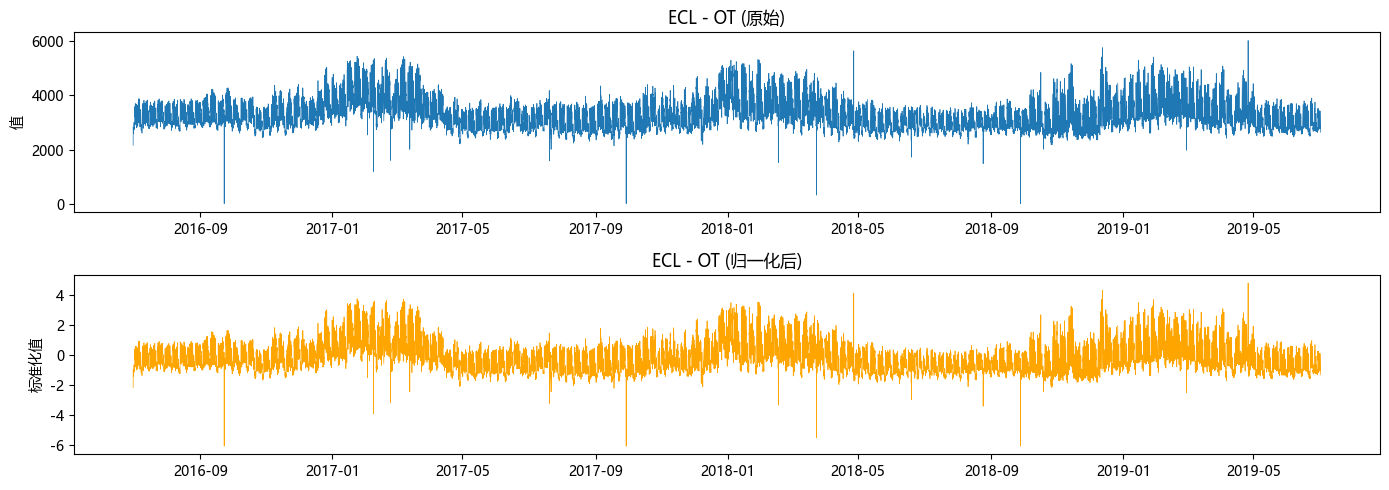

✓ 已保存至 c:\Users\LOKER\Desktop\Research-Training\data\processed\ECL/visualization.png


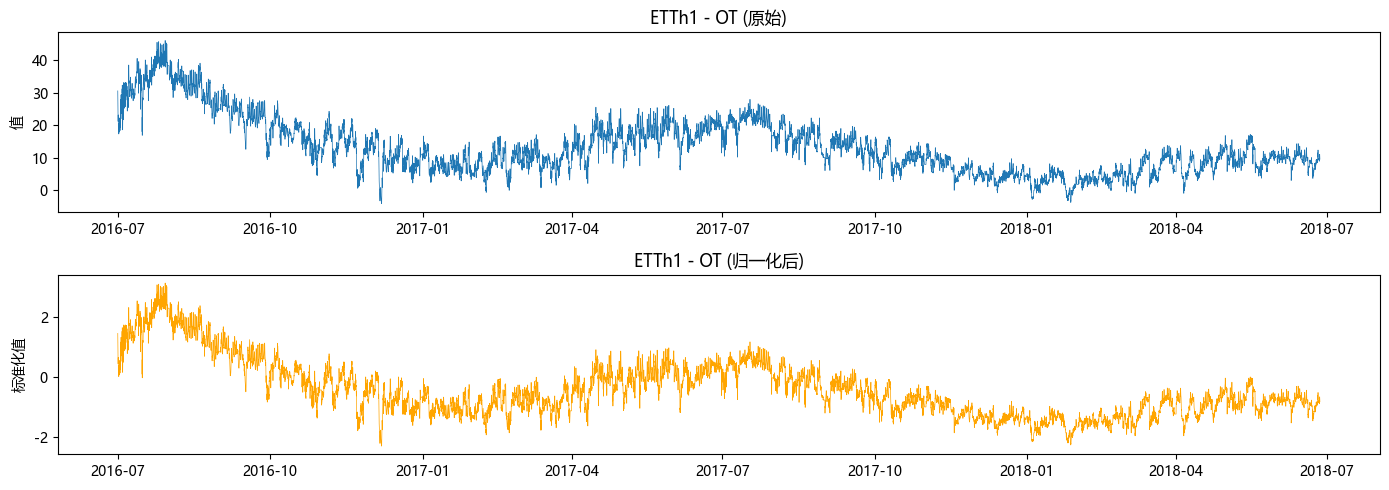

✓ 已保存至 c:\Users\LOKER\Desktop\Research-Training\data\processed\ETTh1/visualization.png


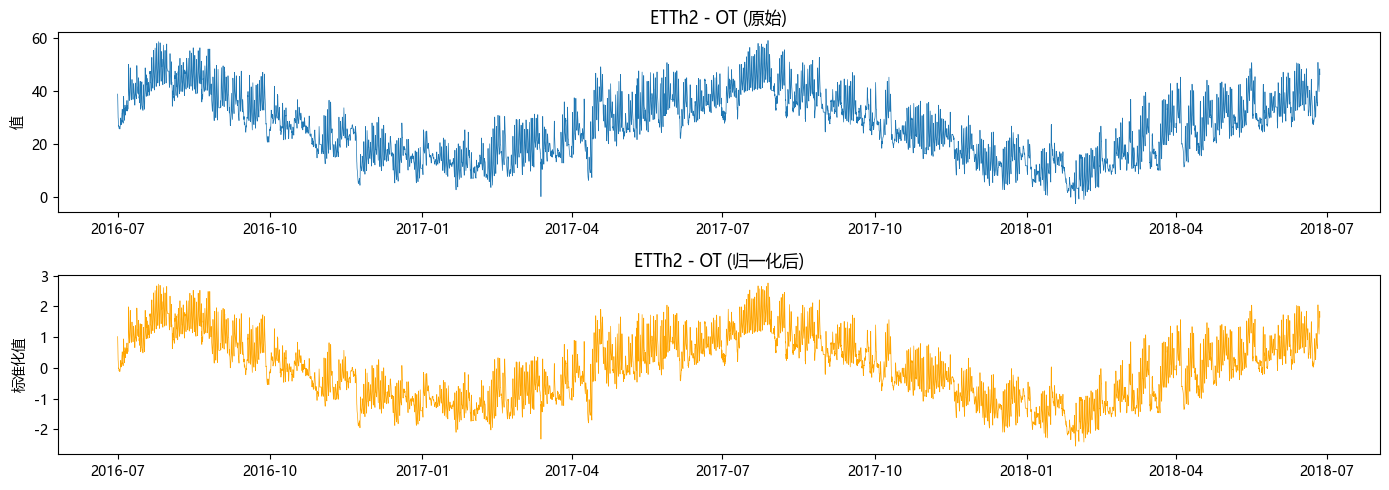

✓ 已保存至 c:\Users\LOKER\Desktop\Research-Training\data\processed\ETTh2/visualization.png


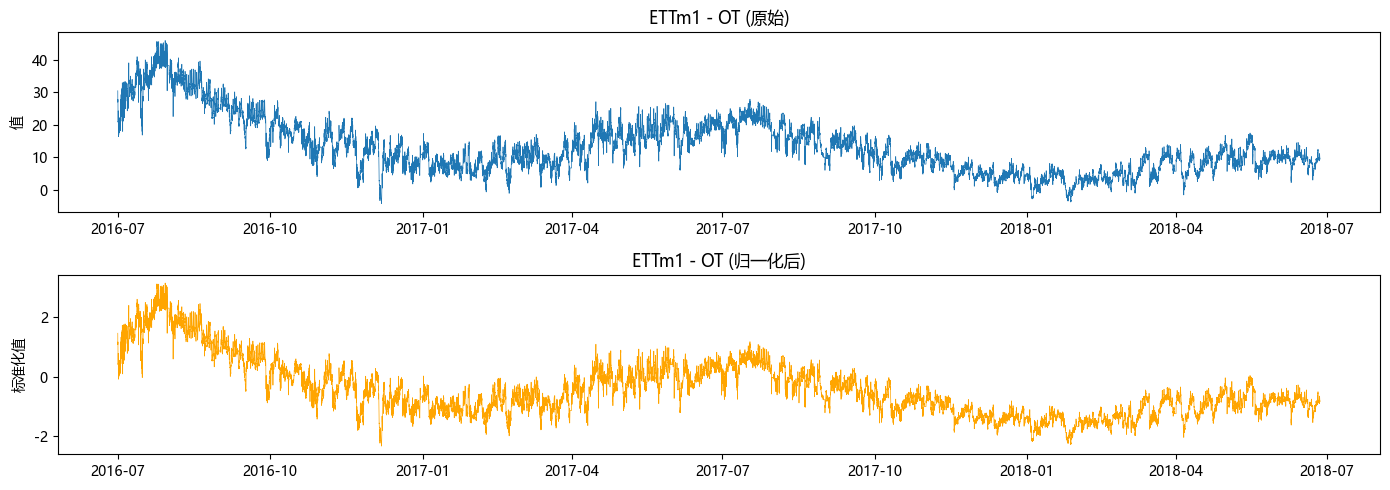

✓ 已保存至 c:\Users\LOKER\Desktop\Research-Training\data\processed\ETTm1/visualization.png


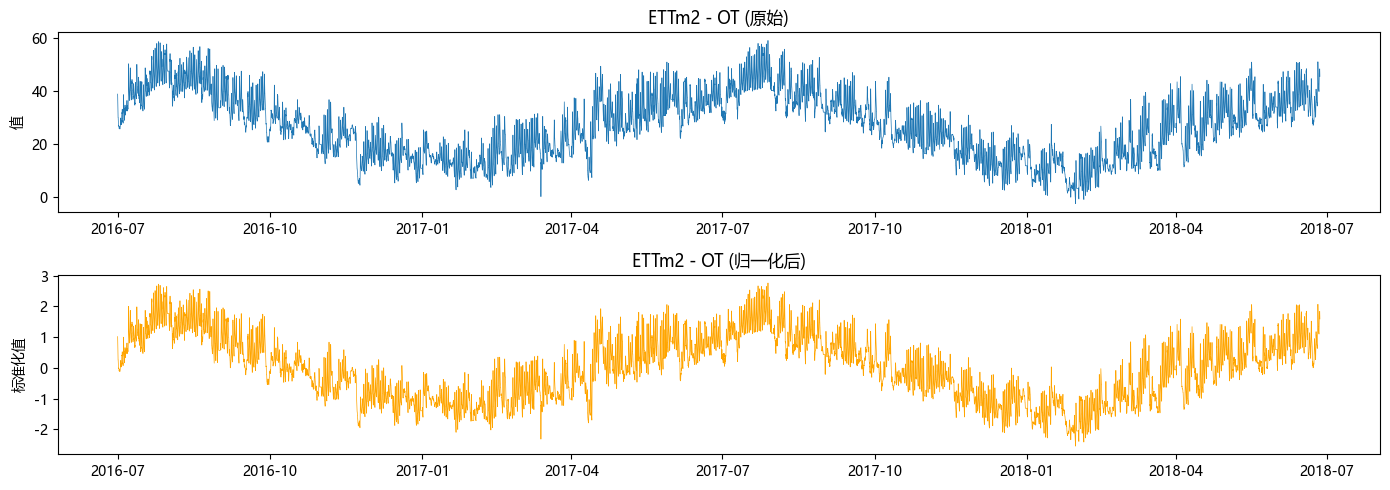

✓ 已保存至 c:\Users\LOKER\Desktop\Research-Training\data\processed\ETTm2/visualization.png


In [21]:
# 可视化每个数据集的目标列（独立读取 meta.json，不依赖运行时状态）
import json

# 直接从 processed 目录读取所有已处理的数据集
processed_datasets = []
for d in sorted(os.listdir(OUTPUT_DIR)):
    meta_path = os.path.join(OUTPUT_DIR, d, 'meta.json')
    if os.path.exists(meta_path):
        with open(meta_path, 'r', encoding='utf-8') as f:
            processed_datasets.append((d, json.load(f)))

print(f'找到 {len(processed_datasets)} 个已处理的数据集: {[d[0] for d in processed_datasets]}')

for name, meta in processed_datasets:
    cfg = DATASET_CONFIG.get(name)
    if cfg is None:
        # 从 meta 中恢复配置
        cfg = {
            'file': f'{name}.csv',
            'date_col': 'date',
            'target_col': meta['target_col'],
        }
    
    fpath = os.path.join(DATA_DIR, cfg['file'])
    if not os.path.exists(fpath):
        print(f'跳过 {name}: 原始文件不存在')
        continue
    
    df = pd.read_csv(fpath)
    df[cfg['date_col']] = pd.to_datetime(df[cfg['date_col']])
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 5))
    
    # 原始序列
    axes[0].plot(df[cfg['date_col']], df[cfg['target_col']], linewidth=0.5)
    axes[0].set_title(f'{name} - {cfg["target_col"]} (原始)')
    axes[0].set_ylabel('值')
    
    # 归一化后
    name_dir = os.path.join(OUTPUT_DIR, name)
    scaler_data = np.load(os.path.join(name_dir, 'scaler.npz'))
    target_idx = meta['target_idx']
    values = df[cfg['target_col']].values.astype(np.float32)
    normed = (values - scaler_data['mean'][target_idx]) / scaler_data['scale'][target_idx]
    axes[1].plot(df[cfg['date_col']], normed, linewidth=0.5, color='orange')
    axes[1].set_title(f'{name} - {cfg["target_col"]} (归一化后)')
    axes[1].set_ylabel('标准化值')
    
    plt.tight_layout()
    plt.savefig(os.path.join(name_dir, 'visualization.png'), dpi=100, bbox_inches='tight')
    plt.show()
    print(f'✓ 已保存至 {name_dir}/visualization.png')

## 8. 加载验证

In [22]:
for name in dataset_stats:
    name_dir = os.path.join(OUTPUT_DIR, name)
    for horizon in PRED_HORIZONS:
        h_dir = os.path.join(name_dir, f'h{horizon}')
        train = np.load(os.path.join(h_dir, 'train.npz'))
        val = np.load(os.path.join(h_dir, 'val.npz'))
        test = np.load(os.path.join(h_dir, 'test.npz'))
        
        assert train['X'].shape[1] == LOOKBACK
        assert train['Y'].shape[1] == horizon
        assert train['X'].shape[2] == train['Y'].shape[2]
    print(f'✓ {name}: 所有 horizon 验证通过')

print(f'\n全部验证通过！处理后的数据保存在: {OUTPUT_DIR}')

✓ ETTh1: 所有 horizon 验证通过
✓ ETTm1: 所有 horizon 验证通过
✓ ECL: 所有 horizon 验证通过

全部验证通过！处理后的数据保存在: c:\Users\LOKER\Desktop\Research-Training\data\processed


## 9. 目录结构

```
data/
├── processed/
│   ├── ETTh1/  (meta.json, scaler.npz, visualization.png)
│   │   ├── h96/   (train.npz, val.npz, test.npz)
│   │   ├── h168/  ...
│   │   └── h336/  ...
│   ├── ETTm1/ ...
│   └── ECL/   ...
├── ETTh1.csv
├── ETTm1.csv
├── ECL.csv
└── ...
```

每个 `.npz` 包含：`X (N, lookback, features)` 和 `Y (N, horizon, features)`